## Sentiment Analysis


In [4]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Regular expressions and string processing
import re
import string

In [8]:

# Model persistence
import pickle

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# ==== NLP Libraries ====
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ==== Machine Learning Libraries ====
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download essential NLTK resources (run once, comment out after first run)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Set up plot aesthetics for better visuals
plt.style.use('ggplot')
sns.set(style='whitegrid')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MRINMAY\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MRINMAY\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MRINMAY\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [9]:
# Load datasets
train_data = pd.read_csv('dataset/train.csv', encoding='latin1')
test_data = pd.read_csv('dataset/test.csv', encoding='latin1')

# Display basic information
print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

# Preview the first few rows of the training data
print("\nFirst 5 rows of training data:")
display(train_data.head())

Training data shape: (27481, 10)
Test data shape: (4815, 9)

First 5 rows of training data:


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [10]:
# Check for missing values
print("\nMissing values in training data:")
print(train_data.isnull().sum())

print("\nMissing values in test data:")
print(test_data.isnull().sum())


Missing values in training data:
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

Missing values in test data:
textID              1281
text                1281
sentiment           1281
Time of Tweet       1281
Age of User         1281
Country             1281
Population -2020    1281
Land Area (Km²)     1281
Density (P/Km²)     1281
dtype: int64


In [11]:
# Sentiment distribution in training data
print("\nSentiment distribution in training data:")
print(train_data['sentiment'].value_counts())


Sentiment distribution in training data:
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


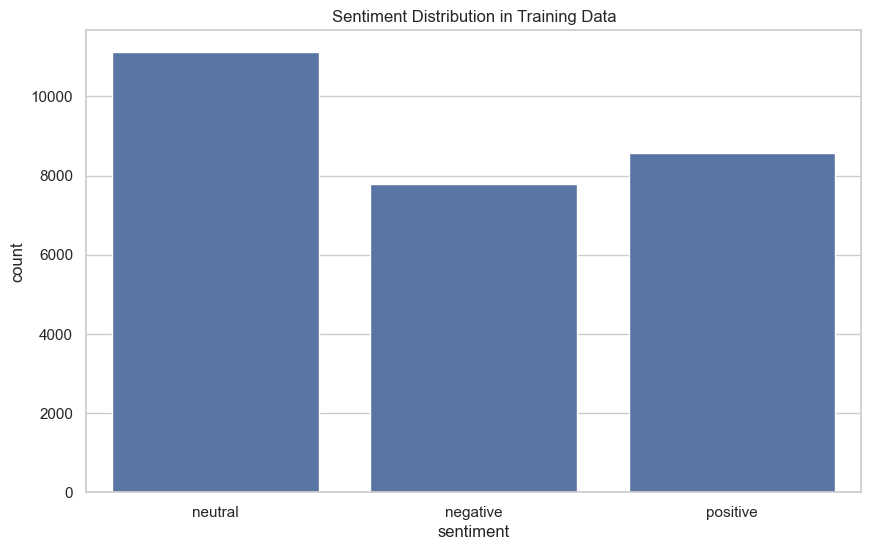

In [12]:
# Visualize sentiment distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=train_data)
plt.title('Sentiment Distribution in Training Data')
plt.show()



In [13]:
# Convert 'text' to string to avoid errors with NaN (float) values
train_data['text'] = train_data['text'].astype(str)
test_data['text'] = test_data['text'].astype(str)

In [16]:
# Explore text length distribution
train_data['text_length'] = train_data['text'].apply(len)
plt.figure(figsize=(12, 6))
sns.histplot(data=train_data, x='text_length', hue='sentiment', bins=50, kde=True)
plt.title('Text Length Distribution by Sentiment')
plt.xlabel('Text Length')
plt.show()



TypeError: object of type 'float' has no len()

### Preprocessing


In [17]:


def clean_text(text):
    """
    Clean and preprocess text data.
    
    Args:
        text (str): Input text
        
    Returns:
        str: Cleaned text
    """
    if pd.isna(text):
        return ""
        
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (keeping the text after #)
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def preprocess_text(text):
    """
    Full preprocessing pipeline: clean, tokenize, remove stopwords, and lemmatize.
    
    Args:
        text (str): Input text
        
    Returns:
        str: Preprocessed text
    """
    if pd.isna(text):
        return ""
        
    # Clean text
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Join tokens back into text
    processed_text = ' '.join(tokens)
    
    return processed_text

In [18]:
print("Preprocessing training data (this may take a few minutes)...")
train_data['processed_text'] = train_data['text'].apply(preprocess_text)

print("Preprocessing test data (this may take a few minutes)...")
test_data['processed_text'] = test_data['text'].apply(preprocess_text)

# Display examples of original vs processed text
print("\nOriginal vs Processed Text Examples:")
for i in range(3):
    print(f"Original: {train_data.iloc[i]['text']}")
    print(f"Processed: {train_data.iloc[i]['processed_text']}")
    print("---")



Preprocessing training data (this may take a few minutes)...
Preprocessing test data (this may take a few minutes)...

Original vs Processed Text Examples:
Original:  I`d have responded, if I were going
Processed: id responded going
---
Original:  Sooo SAD I will miss you here in San Diego!!!
Processed: sooo sad miss san diego
---
Original: my boss is bullying me...
Processed: bos bullying
---



###   Sentiment Label Encoding and Dataset Splitting


In [19]:


sentiment_mapping = {'negative': 0, 'neutral': 2, 'positive': 4}

# Check if sentiment column contains text labels or numerical values
if train_data['sentiment'].dtype == 'object':
    train_data['sentiment_encoded'] = train_data['sentiment'].map(sentiment_mapping)
    test_data['sentiment_encoded'] = test_data['sentiment'].map(sentiment_mapping)
else:
    # If they're already numerical, just copy them
    train_data['sentiment_encoded'] = train_data['sentiment']
    test_data['sentiment_encoded'] = test_data['sentiment']

In [20]:

test_data = test_data.dropna(subset=['text', 'sentiment'])

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_data['processed_text'], 
    train_data['sentiment_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=train_data['sentiment_encoded']
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])



Training set size: 21984
Validation set size: 5497



###   Model Training and Evaluation


In [22]:


def train_evaluate_model(model_name, vectorizer, classifier, X_train, y_train, X_val, y_val):
    """
    Train and evaluate a text classification model.

    Args:
        model_name (str): Name of the model for reporting
        vectorizer: Text vectorizer (CountVectorizer or TfidfVectorizer)
        classifier: Classifier model
        X_train, y_train: Training data
        X_val, y_val: Validation data

    Returns:
        tuple: Trained pipeline and accuracy score
    """
    # Create a pipeline
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', classifier)
    ])
    
    # Train the model
    print(f"Training {model_name}...")
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_val)
    
    # Evaluate the model
    accuracy = accuracy_score(y_val, y_pred)
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    
    # Generate classification report
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    
    # Generate confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()  
    return pipeline, accuracy

In [24]:
# Define vectorizers
count_vectorizer = CountVectorizer(max_features=5000)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Define models to try
models = [
    ('Logistic Regression with Count Vectors', count_vectorizer, LogisticRegression(max_iter=1000, C=1.0)),
    ('Logistic Regression with TF-IDF', tfidf_vectorizer, LogisticRegression(max_iter=1000, C=1.0)),
    ('Naive Bayes with Count Vectors', count_vectorizer, MultinomialNB()),
    ('Naive Bayes with TF-IDF', tfidf_vectorizer, MultinomialNB()),
    ('Linear SVC with TF-IDF', tfidf_vectorizer, LinearSVC(max_iter=1000)),
    ('Random Forest with TF-IDF', tfidf_vectorizer, RandomForestClassifier(n_estimators=100))
]

Training Logistic Regression with Count Vectors...
Logistic Regression with Count Vectors Accuracy: 0.6907

Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.62      0.66      1556
     neutral       0.63      0.74      0.68      2224
    positive       0.77      0.70      0.73      1717

    accuracy                           0.69      5497
   macro avg       0.70      0.68      0.69      5497
weighted avg       0.70      0.69      0.69      5497



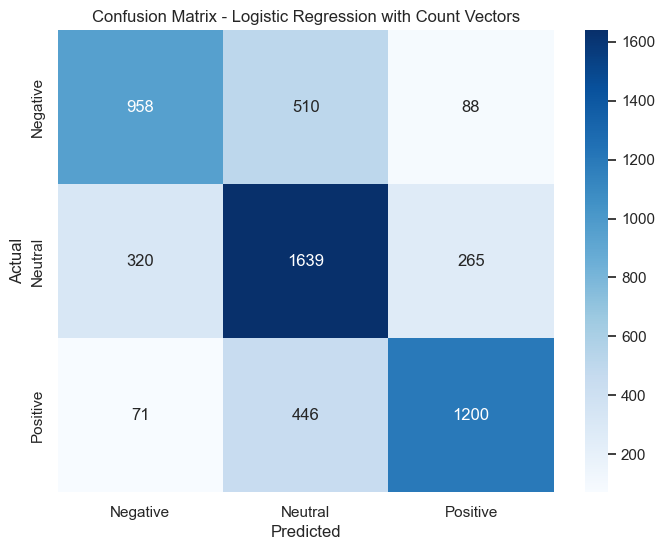

Training Logistic Regression with TF-IDF...
Logistic Regression with TF-IDF Accuracy: 0.6937

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.60      0.66      1556
     neutral       0.62      0.77      0.69      2224
    positive       0.79      0.68      0.73      1717

    accuracy                           0.69      5497
   macro avg       0.71      0.68      0.69      5497
weighted avg       0.71      0.69      0.69      5497



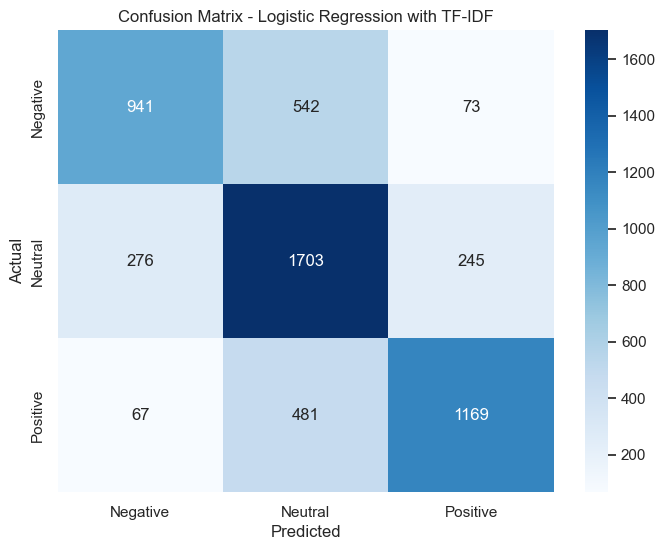

Training Naive Bayes with Count Vectors...
Naive Bayes with Count Vectors Accuracy: 0.6554

Classification Report:
              precision    recall  f1-score   support

    negative       0.68      0.61      0.65      1556
     neutral       0.60      0.68      0.64      2224
    positive       0.71      0.67      0.69      1717

    accuracy                           0.66      5497
   macro avg       0.67      0.65      0.66      5497
weighted avg       0.66      0.66      0.66      5497



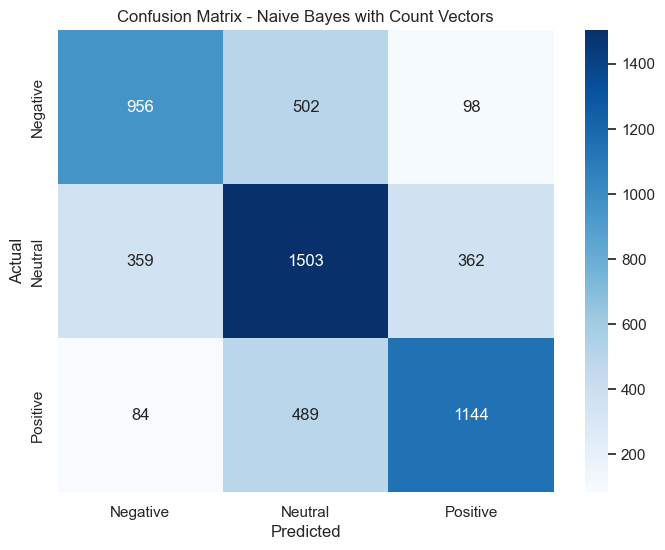

Training Naive Bayes with TF-IDF...
Naive Bayes with TF-IDF Accuracy: 0.6318

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.49      0.59      1556
     neutral       0.55      0.77      0.64      2224
    positive       0.73      0.58      0.65      1717

    accuracy                           0.63      5497
   macro avg       0.67      0.61      0.63      5497
weighted avg       0.66      0.63      0.63      5497



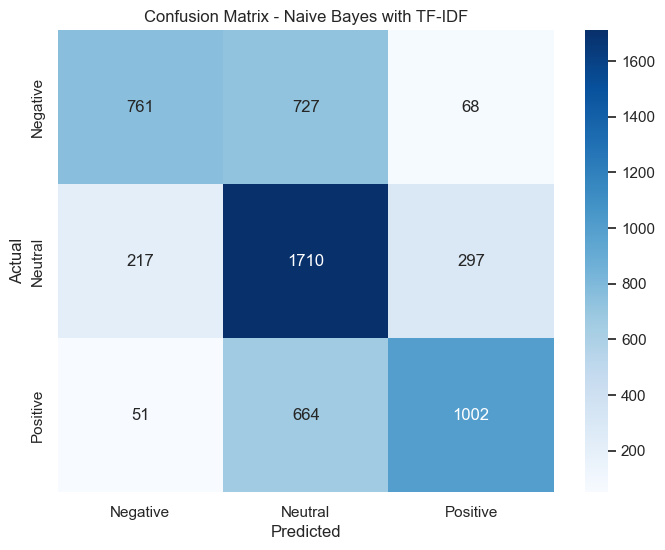

Training Linear SVC with TF-IDF...
Linear SVC with TF-IDF Accuracy: 0.6766

Classification Report:
              precision    recall  f1-score   support

    negative       0.68      0.63      0.66      1556
     neutral       0.63      0.69      0.66      2224
    positive       0.74      0.70      0.72      1717

    accuracy                           0.68      5497
   macro avg       0.69      0.67      0.68      5497
weighted avg       0.68      0.68      0.68      5497



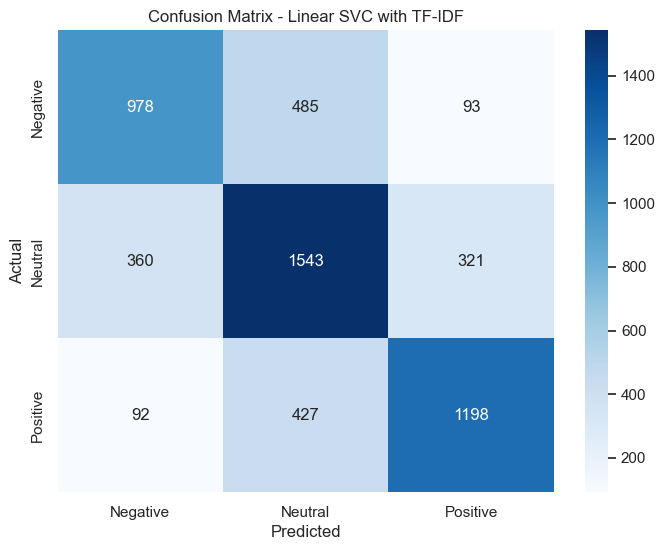

Training Random Forest with TF-IDF...
Random Forest with TF-IDF Accuracy: 0.7088

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.62      0.68      1556
     neutral       0.66      0.75      0.70      2224
    positive       0.75      0.74      0.75      1717

    accuracy                           0.71      5497
   macro avg       0.72      0.70      0.71      5497
weighted avg       0.71      0.71      0.71      5497



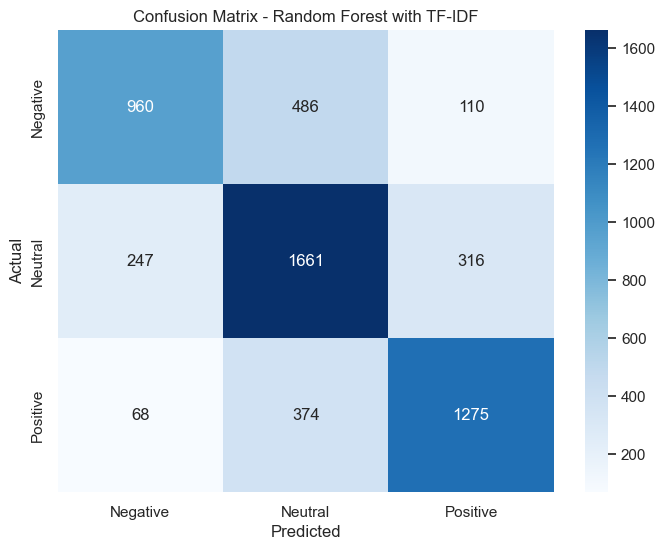

In [25]:
# Train and evaluate each model
results = {}
for model_name, vectorizer, classifier in models:
    pipeline, accuracy = train_evaluate_model(
        model_name, vectorizer, classifier, X_train, y_train, X_val, y_val
    )
    results[model_name] = (pipeline, accuracy)

In [27]:
# Find the best model
best_model_name = max(results.keys(), key=lambda k: results[k][1])
best_pipeline, best_accuracy = results[best_model_name]

print(f"\nBest model: {best_model_name} with accuracy: {best_accuracy:.4f}")




Best model: Random Forest with TF-IDF with accuracy: 0.7088



###    Detailed Evaluation and Error Analysis


In [28]:


# Get the best model pipeline
best_pipeline = results[best_model_name][0]

# Make predictions on the validation set
y_val_pred = best_pipeline.predict(X_val)

def detailed_evaluation(y_true, y_pred, model_name):
    """
    Perform detailed evaluation of model performance
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        model_name: Name of the model for reporting
    Returns:
        pd.DataFrame: Classification report as DataFrame
    """
    # Classification report (as DataFrame for easy plotting)
    report = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    
    print(f"Detailed evaluation for {model_name}:")
    display(report_df)
    
    # Visualize F1-scores by class
    plt.figure(figsize=(10, 6))
    # Exclude 'accuracy', 'macro avg', 'weighted avg' from plot
    class_labels = ['0', '2', '4']  # Assuming 0=negative, 2=neutral, 4=positive
    sns.barplot(x=class_labels, y=report_df.loc[class_labels, 'f1-score'], palette="viridis")
    plt.title(f'F1 Scores by Class - {model_name}')
    plt.ylabel("F1 Score")
    plt.ylim(0, 1)
    plt.xlabel("Sentiment Class")
    plt.xticks([0, 1, 2], ['Negative (0)', 'Neutral (2)', 'Positive (4)'])
    plt.tight_layout()
    plt.show()  
    
    return report_df

Detailed evaluation for Random Forest with TF-IDF:


,precision,recall,f1-score,support
0,0.745483,0.609897,0.670908,1556.000000
2,0.655542,0.741906,0.696056,2224.000000
4,0.752783,0.748398,0.750584,1717.000000
accuracy,0.706567,0.706567,0.706567,0.706567
macro avg,0.717936,0.700067,0.705849,5497.000000
weighted avg,0.711375,0.706567,0.705969,5497.000000


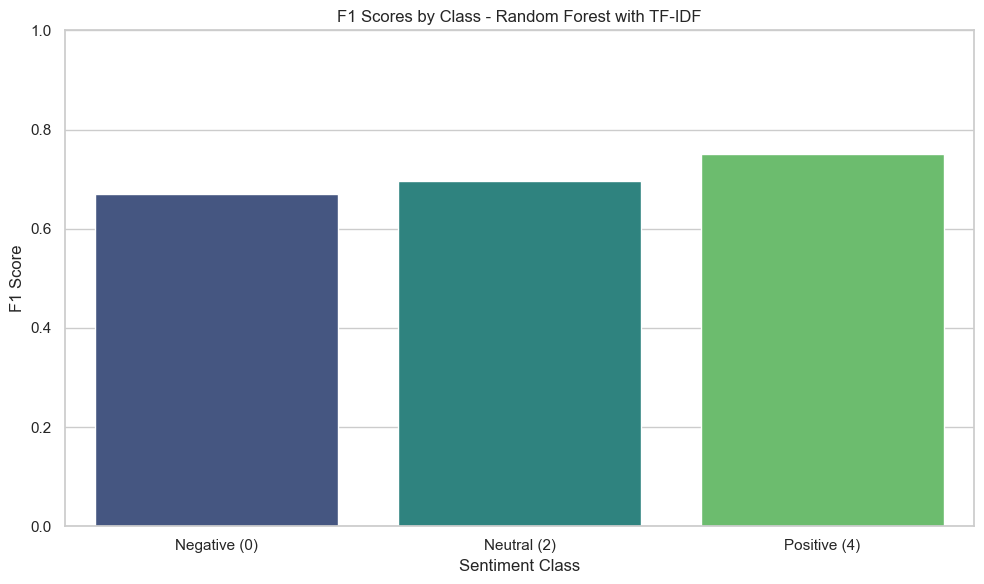

In [38]:
# Perform detailed evaluation
detailed_results = detailed_evaluation(y_val, y_val_pred, best_model_name)

In [29]:


# Find and analyze misclassified examples
misclassified_indices = np.where(y_val.values != y_val_pred)[0]
misclassified_examples = pd.DataFrame({
    'text': X_val.iloc[misclassified_indices].values,
    'true_sentiment': y_val.iloc[misclassified_indices].values,
    'predicted_sentiment': y_val_pred[misclassified_indices]
})

print("\nSample of misclassified examples:")
display(misclassified_examples.head(10))


Sample of misclassified examples:


,text,true_sentiment,predicted_sentiment
0,dont worried im safe sound,positive,negative
1,think disgusting,negative,neutral
2,babysitting kid wont let play wii,negative,neutral
3,seems really quiet tonightam jealous clearly e...,neutral,positive
4,thers many peole tweeting tonight well suppose...,negative,neutral
5,admit im bit bummed wasnt friend walking today,negative,neutral
6,good morninghoping throw back coffee like right,neutral,positive
7,haha co one tweet smile smile smile quoted boy...,positive,neutral
8,richie also saw u american idol great performa...,neutral,positive
9,better back soon dude typical bedtime look tal...,negative,positive



###   Model Saving, Loading, and Inference


In [30]:
###   Model Saving, Loading, and Inference
import pickle

def save_model(model, filename):
    """
    Save a trained model to a file.
    
    Args:
        model: Trained model to save
        filename: Filename to save the model
    """
    with open(filename, 'wb') as file:
        pickle.dump(model, file)
    print(f"Model saved to {filename}")

# Save the best model
model_filename = 'sentiment_analysis_model.pkl'
save_model(best_pipeline, model_filename)

def load_model(filename):
    """
    Load a trained model from a file.
    
    Args:
        filename: Filename to load the model from
        
    Returns:
        Loaded model
    """
    with open(filename, 'rb') as file:
        model = pickle.load(file)
    return model

def predict_sentiment(text, model):
    """
    Predict sentiment for new text.
    
    Args:
        text (str): Input text
        model: Trained model
        
    Returns:
        int: Predicted sentiment (0=negative, 2=neutral, 4=positive)
    """
    # Preprocess the text using the same function as before
    processed_text = preprocess_text(text)
    # Make prediction
    return model.predict([processed_text])[0]

Model saved to sentiment_analysis_model.pkl


In [31]:

loaded_model = load_model(model_filename)

test_texts = [
    "I absolutely love this product! It's amazing!",
    "The service was okay, nothing special.",
    "This is the worst experience I've ever had. Terrible customer service."
]

print("\nTesting model on new examples:")
for text in test_texts:
    sentiment = predict_sentiment(text, loaded_model)
    sentiment_label = {0: "Negative", 2: "Neutral", 4: "Positive"}.get(sentiment, "Unknown")
    print(f"Text: {text}")
    print(f"Predicted sentiment: {sentiment_label} ({sentiment})")
    print("---")




Testing model on new examples:
Text: I absolutely love this product! It's amazing!
Predicted sentiment: Unknown (positive)
---
Text: The service was okay, nothing special.
Predicted sentiment: Unknown (neutral)
---
Text: This is the worst experience I've ever had. Terrible customer service.
Predicted sentiment: Unknown (negative)
---


### Combine All

In [32]:
import pandas as pd
import numpy as np
import re
import string
import pickle
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources if needed
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

def clean_text(text):
    """Clean and preprocess text data"""
    if pd.isna(text):
        return ""
        
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (keeping the text after #)
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def preprocess_text(text):
    """Full preprocessing pipeline: clean, tokenize, remove stopwords, and lemmatize"""
    if pd.isna(text):
        return ""
        
    # Clean text
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Join tokens back into text
    processed_text = ' '.join(tokens)
    
    return processed_text

def load_model(filename='sentiment_analysis_model.pkl'):
    """Load the trained sentiment analysis model"""
    with open(filename, 'rb') as file:
        model = pickle.load(file)
    return model

def predict_sentiment(text, model=None):
    """
    Predict sentiment for a given text
    
    Args:
        text (str): Input text
        model: Pre-loaded model (optional)
        
    Returns:
        dict: Prediction results with sentiment label and score
    """
    # Load model if not provided
    if model is None:
        model = load_model()
    
    # Preprocess text
    processed_text = preprocess_text(text)
    
    # Make prediction
    sentiment_code = model.predict([processed_text])[0]
    
    # Get prediction probability if model supports it
    probabilities = None
    try:
        probabilities = model.predict_proba([processed_text])[0]
    except:
        pass
    
    # Map sentiment code to label
    sentiment_map = {0: "Negative", 2: "Neutral", 4: "Positive"}
    sentiment_label = sentiment_map.get(sentiment_code, "Unknown")
    
    # Return results
    result = {
        'text': text,
        'sentiment_code': int(sentiment_code),
        'sentiment_label': sentiment_label,
    }
    
    if probabilities is not None:
        result['probabilities'] = probabilities.tolist()
    
    return result

def batch_predict(texts, model=None):
    """
    Make sentiment predictions for a batch of texts
    
    Args:
        texts (list): List of input texts
        model: Pre-loaded model (optional)
        
    Returns:
        list: List of prediction results
    """
    # Load model if not provided
    if model is None:
        model = load_model()
    
    results = []
    for text in texts:
        result = predict_sentiment(text, model)
        results.append(result)
    
    return results

# Example usage
if __name__ == "__main__":
    # Example texts
    example_texts = [
        "I absolutely love this product! It's amazing!",
        "The service was okay, nothing special.",
        "This is the worst experience I've ever had. Terrible customer service."
    ]
    
    # Load model
    model = load_model()
    
    # Make predictions
    print("Making predictions for example texts:")
    for text in example_texts:
        result = predict_sentiment(text, model)
        print(f"Text: {result['text']}")
        print(f"Sentiment: {result['sentiment_label']} ({result['sentiment_code']})")
        if 'probabilities' in result:
            print(f"Probabilities: {result['probabilities']}")
        print("---")
    
    # Batch prediction
    print("\nBatch prediction example:")
    batch_results = batch_predict(example_texts, model)
    for i, result in enumerate(batch_results):
        print(f"Example {i+1}: {result['sentiment_label']}")

Making predictions for example texts:


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MRINMAY\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MRINMAY\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MRINMAY\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


ValueError: invalid literal for int() with base 10: 'positive'